In [1]:
import pandas as pd

df = pd.read_csv('Week_2/week_2_final_dataset.csv')

In [2]:
df

,Song,Artist,Popularity,BPM,Time,Dance,Energy,Acoustic,Happy,Live,Loud (Db),Camelot,Artist_Clean,Song_Clean,Genre Tags,lyrics,time_seconds,time_bucket
0,Smalltown Boy,Bronski Beat,3,135,05:03,68,56,53,93,20,-11,6B,Bronski Beat,Smalltown Boy,"80s, new wave, synthpop, pop, synth pop",To your soul\nTo your soul\nCry\nCry\nCry\n\nY...,303,300
1,I'm Still Standing,Elton John,6,177,03:01,49,93,46,79,30,-6,3A,Elton John,I'm Still Standing,"pop, 80s, elton john, rock, classic rock",You could never know what it's like\nYour bloo...,181,180
2,Funky Town,Lipps Inc.,6,122,03:59,91,63,0,34,10,-8,8B,Lipps Inc.,Funky Town,"Disco, 80s, pop, 70s, dance",Gotta make a move to a town that's right for m...,239,230
3,I'm So Excited,The Pointer Sisters,65,92,03:49,69,86,10,69,10,-6,4B,The Pointer Sisters,I'm So Excited,"80s, Disco, pop, dance, soul",Tonight's the night we're gonna make it happen...,229,220
4,Cheri Cheri Lady,Modern Talking,82,114,03:46,68,62,46,85,30,-14,6B,Modern Talking,Cheri Cheri Lady,"80s, Disco, pop, Modern Talking, dance","Oh, I cannot explain\nEvery time, it's the sam...",226,220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4090,Rock with You - Single Version,Michael Jackson,82,114,03:40,81,54,18,85,10,-13,3B,Michael Jackson,Rock with You,"pop, michael jackson, 80s, Disco, dance","Girl, close your eyes\nLet that rhythm get int...",220,220
4091,You Sexy Thing,Hot Chocolate,75,106,04:04,79,73,52,96,10,-5,7B,Hot Chocolate,You Sexy Thing,"Disco, 70s, funk, soul, pop",I believe in miracles\nWhere're you from?\nYou...,244,240
4092,Get It On,T. Rex,72,127,04:22,73,88,18,91,60,-7,10A,T. Rex,Get It On,"glam rock, 70s, classic rock, rock, glam","Well, you're dirty and sweet\nClad in black, d...",262,260
4093,Love Really Hurts Without You,Billy Ocean,1,141,02:58,52,91,0,96,10,-4,7B,Billy Ocean,Love Really Hurts Without You,"80s, pop, soul, 70s, Disco",You run around town like a fool and you think ...,178,170


Removing redundant columns

In [3]:
df = df.drop(columns=['Time', 'time_bucket', 'Artist_Clean', 'Song_Clean'])

In [4]:
df_filtered = df[df['Popularity'] >= 20].reset_index(drop=True)

In [5]:
genre_split = df_filtered['Genre Tags'].str.split(',', expand=True)

genre_split = genre_split.apply(lambda col: col.str.strip())

def clean_genre(genre):
    if pd.isna(genre):
        return None
    genre = genre.strip().lower()              # trim and lowercase
    genre = genre.replace('&', 'and')          # normalize symbols
    genre = genre.replace('-', ' ')            # normalize hyphens
    genre = genre.replace('/', ' ')            # normalize slashes
    genre = genre.replace('  ', ' ')           # remove double spaces
    return genre

# Apply cleaning to each genre column
genre_split_cleaned = genre_split.applymap(clean_genre)

genre_split_cleaned.columns = ['Genre1', 'Genre2', 'Genre3', 'Genre4', 'Genre5']
df_filtered = pd.concat([df_filtered, genre_split_cleaned], axis=1)

/var/folders/nf/jqpg66kx52z7vrjhxgwb3h480000gn/T/ipykernel_32192/1685496884.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  genre_split_cleaned = genre_split.applymap(clean_genre)


In [6]:
df_filtered

,Song,Artist,Popularity,BPM,Dance,Energy,Acoustic,Happy,Live,Loud (Db),Camelot,Genre Tags,lyrics,time_seconds,Genre1,Genre2,Genre3,Genre4,Genre5
0,I'm So Excited,The Pointer Sisters,65,92,69,86,10,69,10,-6,4B,"80s, Disco, pop, dance, soul",Tonight's the night we're gonna make it happen...,229,80s,disco,pop,dance,soul
1,Cheri Cheri Lady,Modern Talking,82,114,68,62,46,85,30,-14,6B,"80s, Disco, pop, Modern Talking, dance","Oh, I cannot explain\nEvery time, it's the sam...",226,80s,disco,pop,modern talking,dance
2,Give It Up,KC & The Sunshine Band,58,126,84,65,8,84,0,-12,5B,"Disco, 70s, 80s, pop, funk",Everybody wants you\nEverybody wants your love...,245,disco,70s,80s,pop,funk
3,It's Raining Men - Single Version,The Weather Girls,50,136,66,93,46,46,70,-6,4A,"Disco, 80s, pop, dance, female vocalists",Hi! Hi! We're your weather girls\n(Uh huh)\nAn...,211,disco,80s,pop,dance,female vocalists
4,Take on Me,a-ha,89,84,57,90,2,88,0,-8,11A,"80s, pop, new wave, synthpop, synth pop","We're talking away\nNo, I don't know what I'm ...",225,80s,pop,new wave,synthpop,synth pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3421,Play That Funky Music,Wild Cherry,76,109,81,67,4,93,0,-12,11B,"funk, Disco, 70s, funky, soul","A-hey, do it now, huh\nYeah, hey\n\nHey-ah, on...",300,funk,disco,70s,funky,soul
3422,Rock with You - Single Version,Michael Jackson,82,114,81,54,18,85,10,-13,3B,"pop, michael jackson, 80s, Disco, dance","Girl, close your eyes\nLet that rhythm get int...",220,pop,michael jackson,80s,disco,dance
3423,You Sexy Thing,Hot Chocolate,75,106,79,73,52,96,10,-5,7B,"Disco, 70s, funk, soul, pop",I believe in miracles\nWhere're you from?\nYou...,244,disco,70s,funk,soul,pop
3424,Get It On,T. Rex,72,127,73,88,18,91,60,-7,10A,"glam rock, 70s, classic rock, rock, glam","Well, you're dirty and sweet\nClad in black, d...",262,glam rock,70s,classic rock,rock,glam


In [7]:
# Combine all genre columns into one Series
all_genres = genre_split_cleaned.stack().reset_index(drop=True)

# Count genre frequency
genre_counts = all_genres.value_counts()

In [8]:
popular_genres = genre_counts[genre_counts > 100]

# Print them
print(popular_genres)

rock                 1019
pop                   950
hip hop               499
indie                 475
alternative           464
classic rock          434
80s                   417
female vocalists      382
70s                   310
singer songwriter     280
rap                   278
dance                 275
rnb                   261
indie rock            250
electronic            246
soul                  242
indie pop             215
country               202
folk                  193
alternative rock      183
myspotigrambot        167
90s                   141
oldies                130
british               128
new wave              126
60s                   119
disco                 113
synthpop              112
love                  105
trap                  101
Name: count, dtype: int64


In [9]:
def top_cooccurring_genres(genre_input):
    genre_cols = ['Genre1', 'Genre2', 'Genre3', 'Genre4', 'Genre5']
    
    # Step 1: Filter rows where the input genre appears
    is_genre = df_filtered[genre_cols].isin([genre_input]).any(axis=1)
    genre_rows = df_filtered[is_genre]
    
    # Step 2: Stack genre columns and exclude the input genre
    stacked_genres = genre_rows[genre_cols].stack()
    other_genres = stacked_genres[stacked_genres != genre_input]
    
    # Step 3: Count each co-occurring genre by unique song
    # We'll count how many *songs* (rows) include each genre alongside the input
    cooccurrence_counts = {}
    for genre in other_genres.unique():
        count = genre_rows[genre_cols].isin([genre]).any(axis=1).sum()
        cooccurrence_counts[genre] = count

    # Step 4: Convert to percentages of total input-genre songs
    total_input_songs = genre_rows.shape[0]
    genre_percentages = {k: round(v / total_input_songs * 100, 2) for k, v in cooccurrence_counts.items()}

    # Step 5: Convert to Series and return top 10
    return pd.Series(genre_percentages).sort_values(ascending=False).head(10)



In [10]:
def top_cooccurrences_list(genre_list, top_n=5):
    result = {}
    for genre in genre_list:
        try:
            top_cooccurring = top_cooccurring_genres(genre)
            result[genre] = top_cooccurring.head(top_n)
        except Exception as e:
            print(f"Error processing '{genre}': {e}")
            result[genre] = None
    return result


In [11]:
common_list = ['rock', 'pop', 'hip hop', 'indie', 'alternative', 'rap', 'dance', 'rnb', 'electronic', 'soul', 'country', 'folk']
maybe_list = ['oldies', 'new wave', 'disco', 'synthpop', 'classic rock']
eras_list = ['60s', '70s', '80s', '90s']
others_list = ['female vocalists', 'singer songwriter', 'myspotigrambot', 'british', 'love', 'trap']

In [12]:
top_cooccurrences = top_cooccurrences_list(common_list)

# Display results
for genre, cooccurrences in top_cooccurrences.items():
    print(f"\nTop co-occurring genres for '{genre}':")
    if cooccurrences is not None:
        print(cooccurrences)
    else:
        print("No data or error.")



Top co-occurring genres for 'rock':
classic rock    38.76
alternative     28.75
pop             24.63
80s             19.92
70s             15.90
dtype: float64

Top co-occurring genres for 'pop':
80s                 28.00
rock                26.42
female vocalists    19.37
dance               18.53
70s                 10.95
dtype: float64

Top co-occurring genres for 'hip hop':
rap               66.96
myspotigrambot    19.13
rnb               18.55
trap              15.65
drake              8.99
dtype: float64

Top co-occurring genres for 'indie':
alternative    35.58
indie rock     35.37
rock           32.42
indie pop      24.84
pop            16.63
dtype: float64

Top co-occurring genres for 'alternative':
rock                63.15
indie               36.42
alternative rock    29.96
indie rock          18.53
pop                 16.81
dtype: float64

Top co-occurring genres for 'rap':
hip hop           83.09
myspotigrambot    21.22
trap              16.19
rnb               11.87
pop

In [13]:
maybe_cooccurrences = top_cooccurrences_list(maybe_list)

# Display results
for genre, cooccurrences in maybe_cooccurrences.items():
    print(f"\nTop co-occurring genres for '{genre}':")
    if cooccurrences is not None:
        print(cooccurrences)
    else:
        print("No data or error.")


Top co-occurring genres for 'oldies':
70s             43.85
60s             41.54
pop             39.23
classic rock    38.46
rock            32.31
dtype: float64

Top co-occurring genres for 'new wave':
80s            85.71
pop            67.46
rock           49.21
synthpop       24.60
alternative    13.49
dtype: float64

Top co-occurring genres for 'disco':
pop      69.03
80s      42.48
dance    41.59
70s      38.94
soul     32.74
dtype: float64

Top co-occurring genres for 'synthpop':
pop           63.39
new wave      27.68
electronic    25.89
electropop    21.43
80s           18.75
dtype: float64

Top co-occurring genres for 'classic rock':
rock    91.22
70s     38.34
80s     29.56
pop     23.09
60s     17.78
dtype: float64


In [14]:
eras_cooccurrences = top_cooccurrences_list(eras_list)

# Display results
for genre, cooccurrences in eras_cooccurrences.items():
    print(f"\nTop co-occurring genres for '{genre}':")
    if cooccurrences is not None:
        print(cooccurrences)
    else:
        print("No data or error.")


Top co-occurring genres for '60s':
classic rock    64.71
rock            58.82
oldies          45.38
pop             26.05
soul            17.65
dtype: float64

Top co-occurring genres for '70s':
classic rock    53.55
rock            52.26
pop             33.55
oldies          18.39
soul            18.06
dtype: float64

Top co-occurring genres for '80s':
pop                 63.79
rock                48.68
classic rock        30.70
new wave            25.90
female vocalists    19.66
dtype: float64

Top co-occurring genres for '90s':
rock                51.77
pop                 41.13
alternative         37.59
female vocalists    26.95
alternative rock    20.57
dtype: float64


In [15]:
others_cooccurrences = top_cooccurrences_list(others_list)

# Display results
for genre, cooccurrences in others_cooccurrences.items():
    print(f"\nTop co-occurring genres for '{genre}':")
    if cooccurrences is not None:
        print(cooccurrences)
    else:
        print("No data or error.")


Top co-occurring genres for 'female vocalists':
pop                  48.17
rock                 22.77
80s                  21.47
singer songwriter    19.37
alternative          19.11
dtype: float64

Top co-occurring genres for 'singer songwriter':
folk                39.64
rock                31.43
female vocalists    26.43
classic rock        22.50
indie               19.29
dtype: float64

Top co-occurring genres for 'myspotigrambot':
hip hop    39.52
rap        35.33
trap       25.75
rnb        16.17
pop rap    11.38
dtype: float64

Top co-occurring genres for 'british':
rock           50.78
pop            38.28
indie          25.78
alternative    22.66
80s            17.19
dtype: float64

Top co-occurring genres for 'love':
pop                 37.14
female vocalists    19.05
rock                17.14
indie               13.33
rnb                 10.48
dtype: float64

Top co-occurring genres for 'trap':
hip hop           53.47
rap               44.55
myspotigrambot    42.57
pop rap 

In [16]:
genre_cols = ['Genre1', 'Genre2', 'Genre3', 'Genre4', 'Genre5']

replacements = {
    'rap': 'hip hop',
    'new wave': '80s',
    'classic rock': 'rock'
}

# Replace values in all genre columns
df_filtered[genre_cols] = df_filtered[genre_cols].applymap(lambda x: replacements.get(x, x))

/var/folders/nf/jqpg66kx52z7vrjhxgwb3h480000gn/T/ipykernel_32192/935651091.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_filtered[genre_cols] = df_filtered[genre_cols].applymap(lambda x: replacements.get(x, x))


In [17]:
df_filtered

,Song,Artist,Popularity,BPM,Dance,Energy,Acoustic,Happy,Live,Loud (Db),Camelot,Genre Tags,lyrics,time_seconds,Genre1,Genre2,Genre3,Genre4,Genre5
0,I'm So Excited,The Pointer Sisters,65,92,69,86,10,69,10,-6,4B,"80s, Disco, pop, dance, soul",Tonight's the night we're gonna make it happen...,229,80s,disco,pop,dance,soul
1,Cheri Cheri Lady,Modern Talking,82,114,68,62,46,85,30,-14,6B,"80s, Disco, pop, Modern Talking, dance","Oh, I cannot explain\nEvery time, it's the sam...",226,80s,disco,pop,modern talking,dance
2,Give It Up,KC & The Sunshine Band,58,126,84,65,8,84,0,-12,5B,"Disco, 70s, 80s, pop, funk",Everybody wants you\nEverybody wants your love...,245,disco,70s,80s,pop,funk
3,It's Raining Men - Single Version,The Weather Girls,50,136,66,93,46,46,70,-6,4A,"Disco, 80s, pop, dance, female vocalists",Hi! Hi! We're your weather girls\n(Uh huh)\nAn...,211,disco,80s,pop,dance,female vocalists
4,Take on Me,a-ha,89,84,57,90,2,88,0,-8,11A,"80s, pop, new wave, synthpop, synth pop","We're talking away\nNo, I don't know what I'm ...",225,80s,pop,80s,synthpop,synth pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3421,Play That Funky Music,Wild Cherry,76,109,81,67,4,93,0,-12,11B,"funk, Disco, 70s, funky, soul","A-hey, do it now, huh\nYeah, hey\n\nHey-ah, on...",300,funk,disco,70s,funky,soul
3422,Rock with You - Single Version,Michael Jackson,82,114,81,54,18,85,10,-13,3B,"pop, michael jackson, 80s, Disco, dance","Girl, close your eyes\nLet that rhythm get int...",220,pop,michael jackson,80s,disco,dance
3423,You Sexy Thing,Hot Chocolate,75,106,79,73,52,96,10,-5,7B,"Disco, 70s, funk, soul, pop",I believe in miracles\nWhere're you from?\nYou...,244,disco,70s,funk,soul,pop
3424,Get It On,T. Rex,72,127,73,88,18,91,60,-7,10A,"glam rock, 70s, classic rock, rock, glam","Well, you're dirty and sweet\nClad in black, d...",262,glam rock,70s,rock,rock,glam


In [18]:
major_genres = {
    'rock', 'pop', 'hip hop', 'indie', 'alternative',
    'dance', 'rnb', 'electronic', 'soul', 'country', 'folk'
}

secondary_genres = major_genres.union({
    '60s', '70s', '80s', '90s', 'disco', 'synthpop'
})

genre_cols = ['Genre1', 'Genre2', 'Genre3', 'Genre4', 'Genre5']

In [19]:
major_genres = {
    'rock', 'pop', 'hip hop', 'indie', 'alternative',
    'dance', 'rnb', 'electronic', 'soul', 'country', 'folk'
}

secondary_genres = major_genres.union({
    '60s', '70s', '80s', '90s', 'disco', 'synthpop'
})

genre_cols = ['Genre1', 'Genre2', 'Genre3', 'Genre4', 'Genre5']

def assign_primary_secondary(row):
    genres = [row[col] for col in genre_cols if pd.notna(row[col])]

    # Step 1: Check for compound genres
    for g in genres:
        if not isinstance(g, str):
            continue
        parts = g.strip().lower().split()
        if len(parts) == 2:
            part1, part2 = parts[0], parts[1]
            if ((part1 in major_genres and part2 in secondary_genres) or
                (part2 in major_genres and part1 in secondary_genres) or
                (part1 in major_genres and part2 in major_genres)):
                return pd.Series([part1, part2])

    # Step 2a: Find primary = first major genre
    primary = next((g for g in genres if g in major_genres), None)

    # Step 2b: Find secondary = first secondary ≠ primary
    if primary:
        secondary = next((g for g in genres if g in secondary_genres and g != primary), None)
    else:
        secondary = None

    return pd.Series([primary, secondary])



In [20]:
# Apply to DataFrame
df_filtered[['primary_genre', 'secondary_genre']] = df_filtered.apply(assign_primary_secondary, axis=1)

In [21]:
df_filtered['primary_genre'].isna().sum()

np.int64(401)

In [22]:
df_filtered

,Song,Artist,Popularity,BPM,Dance,Energy,Acoustic,Happy,Live,Loud (Db),...,Genre Tags,lyrics,time_seconds,Genre1,Genre2,Genre3,Genre4,Genre5,primary_genre,secondary_genre
0,I'm So Excited,The Pointer Sisters,65,92,69,86,10,69,10,-6,...,"80s, Disco, pop, dance, soul",Tonight's the night we're gonna make it happen...,229,80s,disco,pop,dance,soul,pop,80s
1,Cheri Cheri Lady,Modern Talking,82,114,68,62,46,85,30,-14,...,"80s, Disco, pop, Modern Talking, dance","Oh, I cannot explain\nEvery time, it's the sam...",226,80s,disco,pop,modern talking,dance,pop,80s
2,Give It Up,KC & The Sunshine Band,58,126,84,65,8,84,0,-12,...,"Disco, 70s, 80s, pop, funk",Everybody wants you\nEverybody wants your love...,245,disco,70s,80s,pop,funk,pop,disco
3,It's Raining Men - Single Version,The Weather Girls,50,136,66,93,46,46,70,-6,...,"Disco, 80s, pop, dance, female vocalists",Hi! Hi! We're your weather girls\n(Uh huh)\nAn...,211,disco,80s,pop,dance,female vocalists,pop,disco
4,Take on Me,a-ha,89,84,57,90,2,88,0,-8,...,"80s, pop, new wave, synthpop, synth pop","We're talking away\nNo, I don't know what I'm ...",225,80s,pop,80s,synthpop,synth pop,pop,80s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3421,Play That Funky Music,Wild Cherry,76,109,81,67,4,93,0,-12,...,"funk, Disco, 70s, funky, soul","A-hey, do it now, huh\nYeah, hey\n\nHey-ah, on...",300,funk,disco,70s,funky,soul,soul,disco
3422,Rock with You - Single Version,Michael Jackson,82,114,81,54,18,85,10,-13,...,"pop, michael jackson, 80s, Disco, dance","Girl, close your eyes\nLet that rhythm get int...",220,pop,michael jackson,80s,disco,dance,pop,80s
3423,You Sexy Thing,Hot Chocolate,75,106,79,73,52,96,10,-5,...,"Disco, 70s, funk, soul, pop",I believe in miracles\nWhere're you from?\nYou...,244,disco,70s,funk,soul,pop,soul,disco
3424,Get It On,T. Rex,72,127,73,88,18,91,60,-7,...,"glam rock, 70s, classic rock, rock, glam","Well, you're dirty and sweet\nClad in black, d...",262,glam rock,70s,rock,rock,glam,rock,70s


In [23]:
df_filtered = df_filtered.dropna(subset=['primary_genre'])

In [24]:
df_filtered.reset_index(drop=True)

,Song,Artist,Popularity,BPM,Dance,Energy,Acoustic,Happy,Live,Loud (Db),...,Genre Tags,lyrics,time_seconds,Genre1,Genre2,Genre3,Genre4,Genre5,primary_genre,secondary_genre
0,I'm So Excited,The Pointer Sisters,65,92,69,86,10,69,10,-6,...,"80s, Disco, pop, dance, soul",Tonight's the night we're gonna make it happen...,229,80s,disco,pop,dance,soul,pop,80s
1,Cheri Cheri Lady,Modern Talking,82,114,68,62,46,85,30,-14,...,"80s, Disco, pop, Modern Talking, dance","Oh, I cannot explain\nEvery time, it's the sam...",226,80s,disco,pop,modern talking,dance,pop,80s
2,Give It Up,KC & The Sunshine Band,58,126,84,65,8,84,0,-12,...,"Disco, 70s, 80s, pop, funk",Everybody wants you\nEverybody wants your love...,245,disco,70s,80s,pop,funk,pop,disco
3,It's Raining Men - Single Version,The Weather Girls,50,136,66,93,46,46,70,-6,...,"Disco, 80s, pop, dance, female vocalists",Hi! Hi! We're your weather girls\n(Uh huh)\nAn...,211,disco,80s,pop,dance,female vocalists,pop,disco
4,Take on Me,a-ha,89,84,57,90,2,88,0,-8,...,"80s, pop, new wave, synthpop, synth pop","We're talking away\nNo, I don't know what I'm ...",225,80s,pop,80s,synthpop,synth pop,pop,80s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3020,Play That Funky Music,Wild Cherry,76,109,81,67,4,93,0,-12,...,"funk, Disco, 70s, funky, soul","A-hey, do it now, huh\nYeah, hey\n\nHey-ah, on...",300,funk,disco,70s,funky,soul,soul,disco
3021,Rock with You - Single Version,Michael Jackson,82,114,81,54,18,85,10,-13,...,"pop, michael jackson, 80s, Disco, dance","Girl, close your eyes\nLet that rhythm get int...",220,pop,michael jackson,80s,disco,dance,pop,80s
3022,You Sexy Thing,Hot Chocolate,75,106,79,73,52,96,10,-5,...,"Disco, 70s, funk, soul, pop",I believe in miracles\nWhere're you from?\nYou...,244,disco,70s,funk,soul,pop,soul,disco
3023,Get It On,T. Rex,72,127,73,88,18,91,60,-7,...,"glam rock, 70s, classic rock, rock, glam","Well, you're dirty and sweet\nClad in black, d...",262,glam rock,70s,rock,rock,glam,rock,70s


In [25]:
df_filtered = df_filtered.drop(columns=['Genre Tags', 'Genre1', 'Genre2', 'Genre3', 'Genre4', 'Genre5'])

In [26]:
df_filtered

,Song,Artist,Popularity,BPM,Dance,Energy,Acoustic,Happy,Live,Loud (Db),Camelot,lyrics,time_seconds,primary_genre,secondary_genre
0,I'm So Excited,The Pointer Sisters,65,92,69,86,10,69,10,-6,4B,Tonight's the night we're gonna make it happen...,229,pop,80s
1,Cheri Cheri Lady,Modern Talking,82,114,68,62,46,85,30,-14,6B,"Oh, I cannot explain\nEvery time, it's the sam...",226,pop,80s
2,Give It Up,KC & The Sunshine Band,58,126,84,65,8,84,0,-12,5B,Everybody wants you\nEverybody wants your love...,245,pop,disco
3,It's Raining Men - Single Version,The Weather Girls,50,136,66,93,46,46,70,-6,4A,Hi! Hi! We're your weather girls\n(Uh huh)\nAn...,211,pop,disco
4,Take on Me,a-ha,89,84,57,90,2,88,0,-8,11A,"We're talking away\nNo, I don't know what I'm ...",225,pop,80s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3421,Play That Funky Music,Wild Cherry,76,109,81,67,4,93,0,-12,11B,"A-hey, do it now, huh\nYeah, hey\n\nHey-ah, on...",300,soul,disco
3422,Rock with You - Single Version,Michael Jackson,82,114,81,54,18,85,10,-13,3B,"Girl, close your eyes\nLet that rhythm get int...",220,pop,80s
3423,You Sexy Thing,Hot Chocolate,75,106,79,73,52,96,10,-5,7B,I believe in miracles\nWhere're you from?\nYou...,244,soul,disco
3424,Get It On,T. Rex,72,127,73,88,18,91,60,-7,10A,"Well, you're dirty and sweet\nClad in black, d...",262,rock,70s


In [27]:
df_filtered['primary_genre'].value_counts()

primary_genre
pop            546
rock           539
indie          539
hip hop        327
alternative    273
country        193
soul           152
electronic     143
folk           112
dance          111
rnb             86
90s              2
80s              1
disco            1
Name: count, dtype: int64

In [28]:
df_filtered['secondary_genre'].value_counts()

secondary_genre
rock           507
pop            401
80s            366
70s            240
rnb            139
60s            103
alternative     91
90s             89
dance           84
folk            64
disco           48
electronic      47
indie           46
synthpop        40
soul            36
hip hop         24
country          8
Name: count, dtype: int64

In [29]:
df_filtered = df_filtered[~df_filtered['primary_genre'].isin(['90s', '80s', 'disco'])]

In [30]:
df_filtered['primary_genre'].value_counts()

primary_genre
pop            546
rock           539
indie          539
hip hop        327
alternative    273
country        193
soul           152
electronic     143
folk           112
dance          111
rnb             86
Name: count, dtype: int64

In [36]:
# Combine primary and secondary genre into a single string (e.g., "pop rock")
df_filtered['genre_pair'] = df_filtered.apply(
    lambda row: f"{row['primary_genre']} {row['secondary_genre']}" 
    if pd.notna(row['primary_genre']) and pd.notna(row['secondary_genre']) 
    else (row['primary_genre'] if pd.notna(row['primary_genre']) else None),
    axis=1
)

# Count the combinations and sort by frequency
genre_pair_counts = df_filtered['genre_pair'].value_counts()
genre_pair_counts.columns = ['genre_pair', 'count']

df_filtered['genre_pair_counts'] = df_filtered['genre_pair'].map(genre_pair_counts)

df_filtered

/var/folders/nf/jqpg66kx52z7vrjhxgwb3h480000gn/T/ipykernel_32192/2581627534.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['genre_pair'] = df_filtered.apply(
/var/folders/nf/jqpg66kx52z7vrjhxgwb3h480000gn/T/ipykernel_32192/2581627534.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['genre_pair_counts'] = df_filtered['genre_pair'].map(genre_pair_counts)


,Song,Artist,Popularity,BPM,Dance,Energy,Acoustic,Happy,Live,Loud (Db),Camelot,lyrics,time_seconds,primary_genre,secondary_genre,genre_pair,genre_pair_counts
0,I'm So Excited,The Pointer Sisters,65,92,69,86,10,69,10,-6,4B,Tonight's the night we're gonna make it happen...,229,pop,80s,pop 80s,168
1,Cheri Cheri Lady,Modern Talking,82,114,68,62,46,85,30,-14,6B,"Oh, I cannot explain\nEvery time, it's the sam...",226,pop,80s,pop 80s,168
2,Give It Up,KC & The Sunshine Band,58,126,84,65,8,84,0,-12,5B,Everybody wants you\nEverybody wants your love...,245,pop,disco,pop disco,14
3,It's Raining Men - Single Version,The Weather Girls,50,136,66,93,46,46,70,-6,4A,Hi! Hi! We're your weather girls\n(Uh huh)\nAn...,211,pop,disco,pop disco,14
4,Take on Me,a-ha,89,84,57,90,2,88,0,-8,11A,"We're talking away\nNo, I don't know what I'm ...",225,pop,80s,pop 80s,168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3421,Play That Funky Music,Wild Cherry,76,109,81,67,4,93,0,-12,11B,"A-hey, do it now, huh\nYeah, hey\n\nHey-ah, on...",300,soul,disco,soul disco,15
3422,Rock with You - Single Version,Michael Jackson,82,114,81,54,18,85,10,-13,3B,"Girl, close your eyes\nLet that rhythm get int...",220,pop,80s,pop 80s,168
3423,You Sexy Thing,Hot Chocolate,75,106,79,73,52,96,10,-5,7B,I believe in miracles\nWhere're you from?\nYou...,244,soul,disco,soul disco,15
3424,Get It On,T. Rex,72,127,73,88,18,91,60,-7,10A,"Well, you're dirty and sweet\nClad in black, d...",262,rock,70s,rock 70s,148


In [38]:
df_filtered['genre_pair'] = df_filtered.apply(
    lambda row: row['primary_genre'] if row['genre_pair_counts'] < 15 else row['genre_pair'],
    axis=1
)

df_filtered

/var/folders/nf/jqpg66kx52z7vrjhxgwb3h480000gn/T/ipykernel_32192/2655739726.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['genre_pair'] = df_filtered.apply(


,Song,Artist,Popularity,BPM,Dance,Energy,Acoustic,Happy,Live,Loud (Db),Camelot,lyrics,time_seconds,primary_genre,secondary_genre,genre_pair,genre_pair_counts
0,I'm So Excited,The Pointer Sisters,65,92,69,86,10,69,10,-6,4B,Tonight's the night we're gonna make it happen...,229,pop,80s,pop 80s,168
1,Cheri Cheri Lady,Modern Talking,82,114,68,62,46,85,30,-14,6B,"Oh, I cannot explain\nEvery time, it's the sam...",226,pop,80s,pop 80s,168
2,Give It Up,KC & The Sunshine Band,58,126,84,65,8,84,0,-12,5B,Everybody wants you\nEverybody wants your love...,245,pop,disco,pop,14
3,It's Raining Men - Single Version,The Weather Girls,50,136,66,93,46,46,70,-6,4A,Hi! Hi! We're your weather girls\n(Uh huh)\nAn...,211,pop,disco,pop,14
4,Take on Me,a-ha,89,84,57,90,2,88,0,-8,11A,"We're talking away\nNo, I don't know what I'm ...",225,pop,80s,pop 80s,168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3421,Play That Funky Music,Wild Cherry,76,109,81,67,4,93,0,-12,11B,"A-hey, do it now, huh\nYeah, hey\n\nHey-ah, on...",300,soul,disco,soul disco,15
3422,Rock with You - Single Version,Michael Jackson,82,114,81,54,18,85,10,-13,3B,"Girl, close your eyes\nLet that rhythm get int...",220,pop,80s,pop 80s,168
3423,You Sexy Thing,Hot Chocolate,75,106,79,73,52,96,10,-5,7B,I believe in miracles\nWhere're you from?\nYou...,244,soul,disco,soul disco,15
3424,Get It On,T. Rex,72,127,73,88,18,91,60,-7,10A,"Well, you're dirty and sweet\nClad in black, d...",262,rock,70s,rock 70s,148


In [40]:
df_filtered.drop(columns='genre_pair_counts', inplace=True)

/var/folders/nf/jqpg66kx52z7vrjhxgwb3h480000gn/T/ipykernel_32192/269780956.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.drop(columns='genre_pair_counts', inplace=True)


In [41]:
genre_pair_counts = df_filtered['genre_pair'].value_counts()
genre_pair_counts.columns = ['genre_pair', 'count']

print(genre_pair_counts)

genre_pair
hip hop              272
indie rock           207
indie pop            203
pop 80s              168
alternative rock     163
rock 70s             148
rock 80s             144
country              130
pop                  124
rock                 119
electronic            88
rnb                   86
pop rock              75
folk                  67
country pop           63
indie                 62
alternative           59
rock 60s              54
alternative rnb       51
dance                 49
indie folk            48
dance pop             46
pop 70s               46
pop dance             46
folk rock             45
soul                  45
rock alternative      43
hip hop rnb           36
soul 70s              35
rock 90s              31
electronic pop        28
pop 90s               27
electronic dance      27
soul rnb              23
pop 60s               22
indie alternative     19
pop synthpop          19
hip hop 90s           19
pop rnb               19
soul 80s      

In [42]:
df_filtered = df_filtered.drop(columns=['secondary_genre'])

In [43]:
df_filtered = df_filtered.rename(columns={
    'Loud (Db)': 'Loud',
    'lyrics': 'Lyrics',
    'time_seconds': 'Time',
    'primary_genre': 'Genre',
    'genre_pair': 'Subgenre'
})

In [44]:
df_filtered

,Song,Artist,Popularity,BPM,Dance,Energy,Acoustic,Happy,Live,Loud,Camelot,Lyrics,Time,Genre,Subgenre
0,I'm So Excited,The Pointer Sisters,65,92,69,86,10,69,10,-6,4B,Tonight's the night we're gonna make it happen...,229,pop,pop 80s
1,Cheri Cheri Lady,Modern Talking,82,114,68,62,46,85,30,-14,6B,"Oh, I cannot explain\nEvery time, it's the sam...",226,pop,pop 80s
2,Give It Up,KC & The Sunshine Band,58,126,84,65,8,84,0,-12,5B,Everybody wants you\nEverybody wants your love...,245,pop,pop
3,It's Raining Men - Single Version,The Weather Girls,50,136,66,93,46,46,70,-6,4A,Hi! Hi! We're your weather girls\n(Uh huh)\nAn...,211,pop,pop
4,Take on Me,a-ha,89,84,57,90,2,88,0,-8,11A,"We're talking away\nNo, I don't know what I'm ...",225,pop,pop 80s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3421,Play That Funky Music,Wild Cherry,76,109,81,67,4,93,0,-12,11B,"A-hey, do it now, huh\nYeah, hey\n\nHey-ah, on...",300,soul,soul disco
3422,Rock with You - Single Version,Michael Jackson,82,114,81,54,18,85,10,-13,3B,"Girl, close your eyes\nLet that rhythm get int...",220,pop,pop 80s
3423,You Sexy Thing,Hot Chocolate,75,106,79,73,52,96,10,-5,7B,I believe in miracles\nWhere're you from?\nYou...,244,soul,soul disco
3424,Get It On,T. Rex,72,127,73,88,18,91,60,-7,10A,"Well, you're dirty and sweet\nClad in black, d...",262,rock,rock 70s


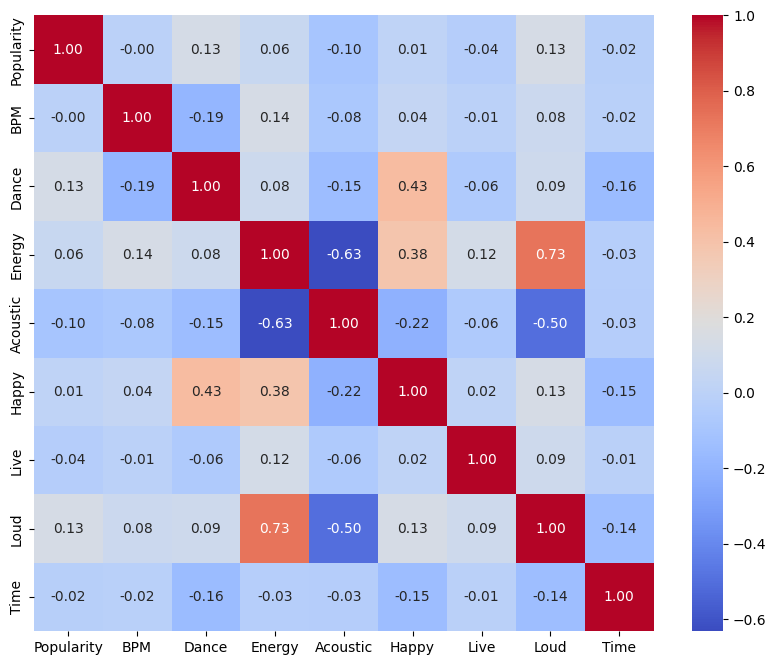

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

df_numeric = df_filtered.drop(columns=['Song', 'Artist', 'Camelot', 'Lyrics', 'Genre', 'Subgenre'])

corr_matrix = df_numeric.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [46]:
df_filtered.to_csv('Week_3/week_3_final_dataset.csv', index=False)